# Chapter 6 - Analysis Notebook

Reproduces every figure and in-text statistic in **Chapter 6: Placement in the Least Restrictive Environment**.

Inputs: `idea_db_v2.sqlite`. Outputs: PNG figures in `figures/`. Run top-to-bottom; no network required.

Uses `v_lre_inclusion` (School Age 6-21 only; SY2012-13 to SY2024-25). **SY2019-20 is excluded** from every aggregate: 34 of 51 jurisdictions have no environment rows that year (age-5 reclassification transition), so the national denominator is missing ~2/3 of students and any national rate for that year is an artifact.

In [1]:
import sqlite3, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB = '../_shared/idea_db_v2.sqlite'
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)
con = sqlite3.connect(DB)
def q(sql, params=()):
    return pd.read_sql_query(sql, con, params=params)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
DEFECT_YEAR = '2019-20'

## 0. Document the SY2019-20 defect

Confirm how many states have a zero/NULL environment total in each year before trusting any aggregate.

In [2]:
cov = q('''SELECT school_year AS sy,
             SUM(CASE WHEN n_total_school_age=0 OR n_total_school_age IS NULL THEN 1 ELSE 0 END) AS zero_states,
             COUNT(*) AS n_states
           FROM v_lre_inclusion WHERE disability_code='ALL' GROUP BY 1 ORDER BY 1''')
cov

,sy,zero_states,n_states
0,2012-13,0,51
1,2013-14,0,51
2,2014-15,1,51
3,2015-16,0,51
4,2016-17,1,51
5,2017-18,3,51
6,2018-19,1,51
7,2019-20,34,51
8,2020-21,1,51
9,2021-22,0,51


## 1. National inclusion trend (Figure 6.1)

Enrollment-weighted national inclusion-80 rate. SY2019-20 is blanked out (defective).

,sy,rate
0,2012-13,61.16
1,2013-14,61.77
2,2014-15,62.24
3,2015-16,62.53
4,2016-17,62.89
5,2017-18,63.36
6,2018-19,63.94
7,2019-20,NaN
8,2020-21,65.98
9,2021-22,66.54


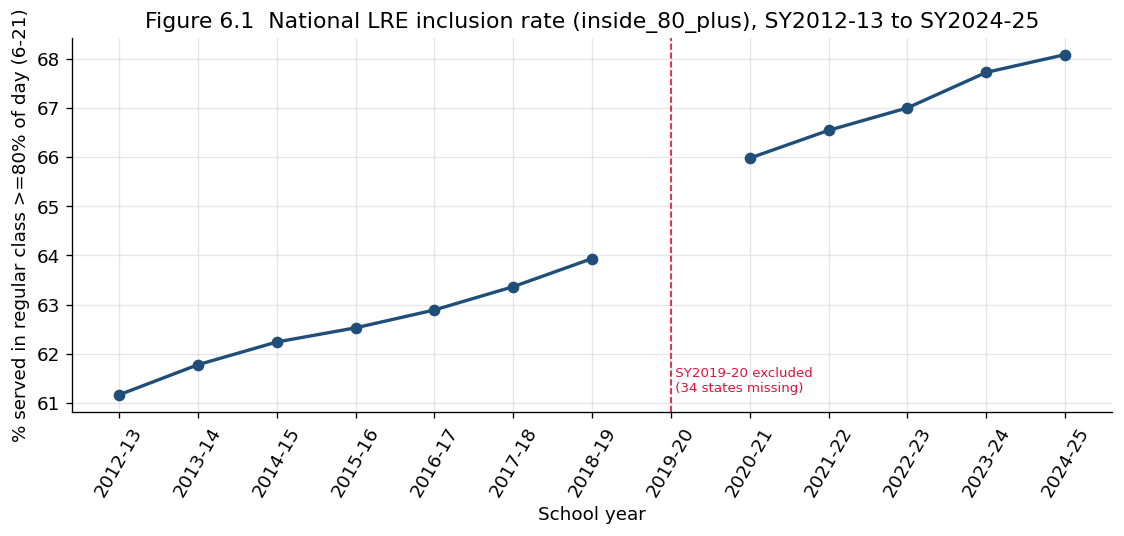

In [3]:
nat = q('''SELECT school_year AS sy, SUM(n_inside_80) AS inc, SUM(n_total_school_age) AS tot
           FROM v_lre_inclusion WHERE disability_code='ALL' GROUP BY 1 ORDER BY 1''')
nat['rate'] = 100.0 * nat['inc'] / nat['tot']
nat.loc[nat['sy']==DEFECT_YEAR, 'rate'] = np.nan
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.plot(nat['sy'], nat['rate'], marker='o', color='#1f4e79', lw=2)
ax.axvline(DEFECT_YEAR, color='crimson', ls='--', lw=1)
ax.text(DEFECT_YEAR, nat['rate'].min(), ' SY2019-20 excluded\n (34 states missing)', color='crimson', fontsize=8, va='bottom')
ax.set_ylabel('% served in regular class >=80% of day (6-21)'); ax.set_xlabel('School year')
ax.tick_params(axis='x', rotation=60)
ax.set_title('Figure 6.1  National LRE inclusion rate (inside_80_plus), SY2012-13 to SY2024-25')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig6_1_national_inclusion.png', bbox_inches='tight')
nat[['sy','rate']].round(2)

## 2. Inclusion by disability category (Figure 6.2, Table 6.1 inputs)

Inclusion is strongly category-dependent. SLI is near-fully included; ID, MD, and AUT are placed in regular class far less often.

sy,2012-13,2024-25
dc,,
SLD,66.7,78.8
SLI,86.8,89.1
OHI,63.7,72.4
AUT,39.5,40.8
ID,16.5,20.9
ED,44.0,58.2
MD,12.9,24.6


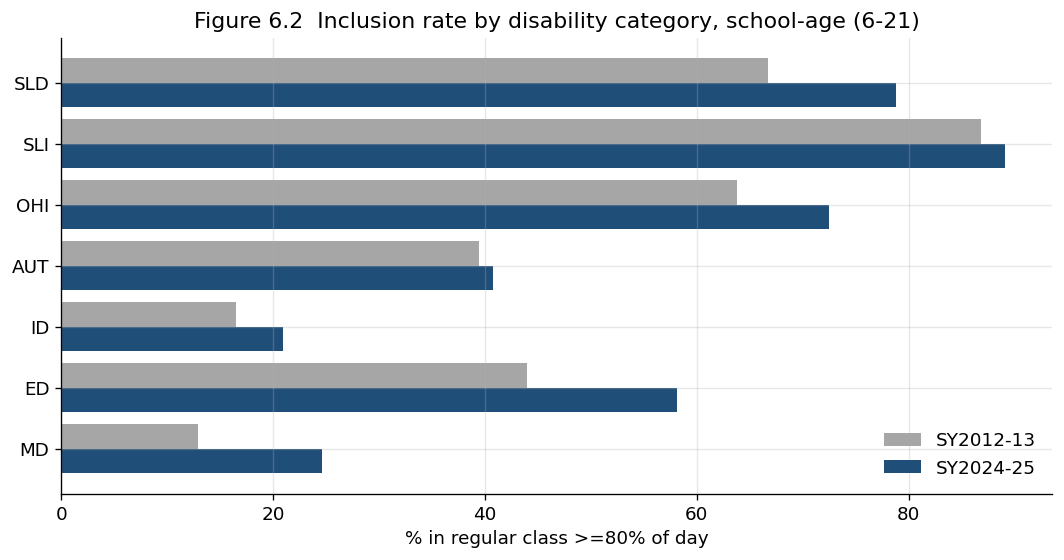

In [4]:
cats = ['SLD','SLI','OHI','AUT','ID','ED','MD']
rows = []
for dc in cats:
    for sy in ['2012-13','2024-25']:
        d = q(f"SELECT SUM(n_inside_80) i, SUM(n_total_school_age) t FROM v_lre_inclusion WHERE disability_code='{dc}' AND school_year='{sy}'")
        rows.append((dc, sy, 100.0*d['i'][0]/d['t'][0]))
ic = pd.DataFrame(rows, columns=['dc','sy','rate']).pivot(index='dc', columns='sy', values='rate').loc[cats]
y = np.arange(len(cats))
fig, ax = plt.subplots(figsize=(9,4.8))
ax.barh(y-0.2, ic['2012-13'], 0.4, label='SY2012-13', color='#a6a6a6')
ax.barh(y+0.2, ic['2024-25'], 0.4, label='SY2024-25', color='#1f4e79')
ax.set_yticks(y); ax.set_yticklabels(cats); ax.invert_yaxis()
ax.set_xlabel('% in regular class >=80% of day'); ax.legend(frameon=False)
ax.set_title('Figure 6.2  Inclusion rate by disability category, school-age (6-21)')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig6_2_by_category.png', bbox_inches='tight')
ic.round(1)

## 3. State dispersion, SY2023-24 (Figure 6.3)

SY2023-24 state range: 44.8% - 82.8% (ratio 1.85x)


,st,r
0,NJ,44.8
1,HI,53.2
2,IL,53.5
3,MO,56.4
46,CO,80.8
47,VT,81.9
48,NE,82.1
49,AL,82.8


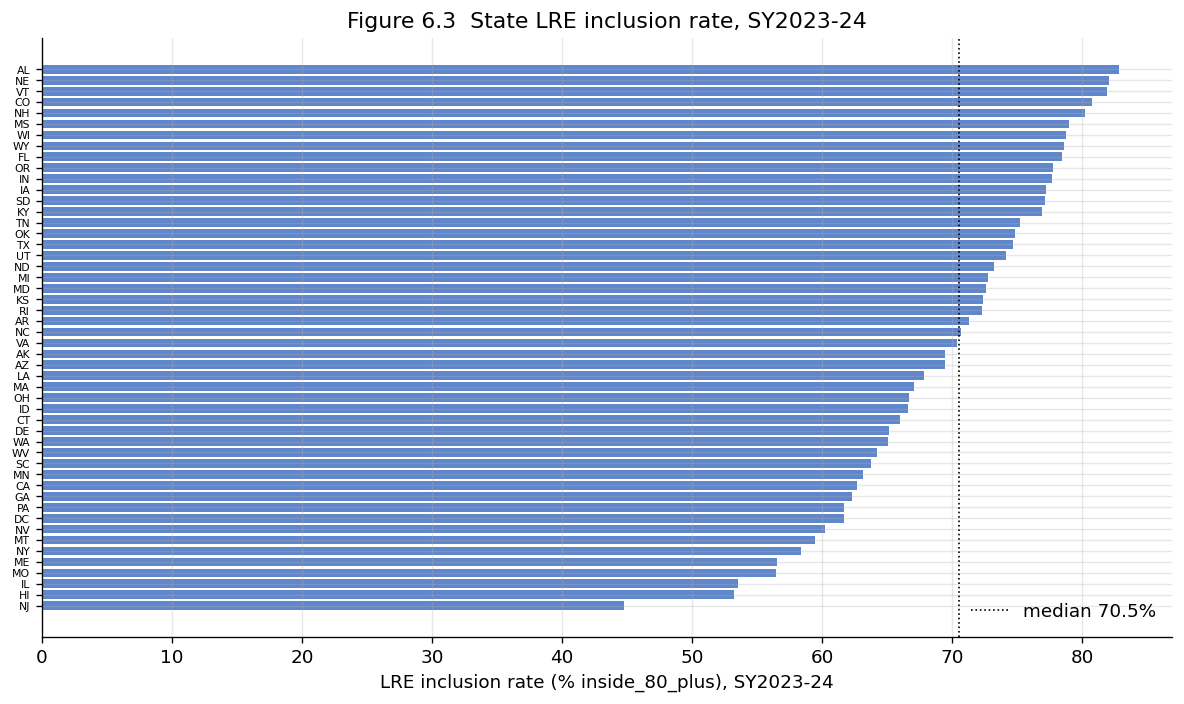

In [5]:
last = q('''SELECT state_code AS st, inclusion_80_rate AS r FROM v_lre_inclusion
            WHERE disability_code='ALL' AND school_year='2023-24' AND inclusion_80_rate IS NOT NULL
            ORDER BY r''')
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(last['st'], last['r'], color='#4472c4', alpha=0.85)
ax.axvline(last['r'].median(), color='black', ls=':', lw=1, label=f"median {last['r'].median():.1f}%")
ax.set_xlabel('LRE inclusion rate (% inside_80_plus), SY2023-24')
ax.tick_params(axis='y', labelsize=6.5); ax.legend(frameon=False)
ax.set_title('Figure 6.3  State LRE inclusion rate, SY2023-24')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fig6_3_state_dispersion.png', bbox_inches='tight')
print(f"SY2023-24 state range: {last['r'].min():.1f}% - {last['r'].max():.1f}% (ratio {last['r'].max()/last['r'].min():.2f}x)")
pd.concat([last.head(4), last.tail(4)]).round(1)

In [6]:
con.close()
print('Chapter 6 figures written to', FIGDIR)

Chapter 6 figures written to figures
